[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Tommy-Burns/easy-eo/blob/main/examples/02_data_access/01_sample_data.ipynb)

# The sample data helper

`eeo.datasets` ships a small curated sample so tutorials and bug reports run in minutes without hunting for data. This notebook covers the whole helper.

- **Data:** the bundled sample
- **Network:** needed once per file, then everything is cached

In [ ]:
# Running in Colab? Install Easy-EO. Does nothing anywhere else.
import sys

if "google.colab" in sys.modules:
    %pip install -q "easy-eo"


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

# Keeps the figures stored in this notebook small; raise it for print-quality output.
plt.rcParams["figure.dpi"] = 80

## The namespace

`load_sample_dataset()` returns an object whose attributes are the individual sample files. It is instant and touches no network - nothing is downloaded until a file is actually opened.

In [2]:
from eeo.datasets import load_sample_dataset

sd = load_sample_dataset()
sd

SampleDataset(sentinel2_stacked, sentinel2_cog_stacked, sentinel2_blue, sentinel2_green, sentinel2_red, sentinel2_nir, copernicus_dem, copernicus_dem_cog, boundary)

In [3]:
for handle in sd:
    print(f"{handle.name:24s} {handle.kind:7s} {handle.description}")

sentinel2_stacked        raster  Sentinel-2 L2A 4-band stack (blue/green/red/nir), 1024x1024 @ 10 m, EPSG:32633.
sentinel2_cog_stacked    raster  Cloud-Optimized GeoTIFF variant of the 4-band Sentinel-2 stack (HTTP range-read demos).
sentinel2_blue           raster  Sentinel-2 L2A band B02 (blue), 1024x1024 @ 10 m, EPSG:32633.
sentinel2_green          raster  Sentinel-2 L2A band B03 (green), 1024x1024 @ 10 m, EPSG:32633.
sentinel2_red            raster  Sentinel-2 L2A band B04 (red), 1024x1024 @ 10 m, EPSG:32633.
sentinel2_nir            raster  Sentinel-2 L2A band B08 (nir), 1024x1024 @ 10 m, EPSG:32633.
copernicus_dem           raster  Copernicus GLO-30 DEM warped onto the Sentinel-2 grid, float32 metres.
copernicus_dem_cog       raster  Cloud-Optimized GeoTIFF variant of the Copernicus GLO-30 DEM.
boundary                 vector  Region-of-interest polygon (GeoPackage, EPSG:4326) inside the Sentinel-2 footprint.


Addressing files by attribute rather than by string key means your editor autocompletes them and a typo is an `AttributeError` at the point of the mistake, rather than a confusing failure later.

In [4]:
try:
    sd.sentinel2_swir
except AttributeError as exc:
    print("AttributeError:", exc)

AttributeError: 'SampleDataset' object has no attribute 'sentinel2_swir'


## What is in the sample

One Sentinel-2 L2A subset and a matching DEM, all on the same 1024x1024 grid at 10 m in EPSG:32633:

| handle | what it is |
| --- | --- |
| `sentinel2_stacked` | blue, green, red, nir as one 4-band GeoTIFF |
| `sentinel2_cog_stacked` | the same, as a Cloud-Optimized GeoTIFF |
| `sentinel2_blue` / `_green` / `_red` / `_nir` | the four bands as separate files |
| `copernicus_dem` | Copernicus GLO-30 DEM, float32 metres |
| `copernicus_dem_cog` | the same, as a COG |
| `boundary` | a region-of-interest polygon (GeoPackage, EPSG:4326) |

There is **no SWIR band**, which is why `ndmi` and `ndbi` are demonstrated on STAC-fetched scenes rather than on the sample.

## Opening a raster

Pass the handle straight to `load_raster`. The file is downloaded and checksum-verified on first use, then reused from the cache.

In [5]:
from eeo import load_raster

scene = load_raster(sd.sentinel2_stacked)
scene.describe()

EEORasterDataset
  source      : /home/tommy/.cache/easy-eo/sentinel2_small.tif
  driver      : GTiff
  bands       : 4
  band names  : 1: blue, 2: green, 3: red, 4: nir
  size        : 1024 × 1024  (height × width)
  dtype       : uint16
  crs         : EPSG:32633 — WGS 84 / UTM zone 33N
  pixel size  : 10 × 10  (CRS units)
  extent      : 377720, 5340230, 387960, 5350470  (minx, miny, maxx, maxy)
  nodata      : 0.0
  timestamp   : none
  attrs       : none


Band names come from the file's own GDAL descriptions, so they are there without you supplying anything.

['blue', 'green', 'red', 'nir']


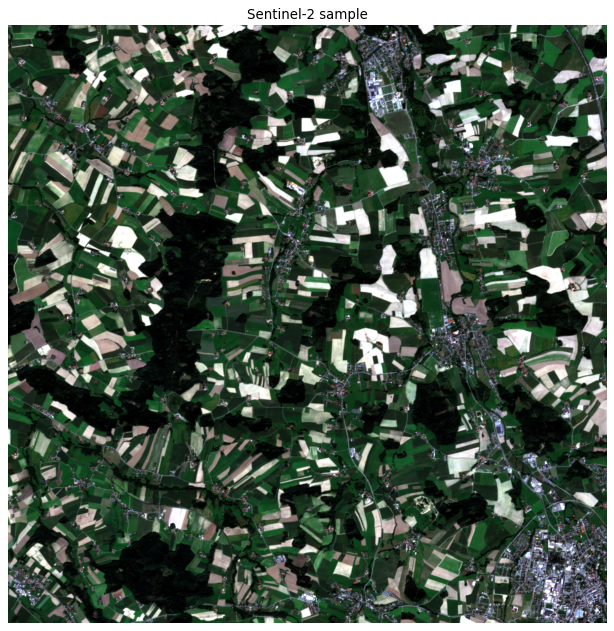

In [6]:
print(scene.band_names)
scene.plot_composite(["red", "green", "blue"], pmin=2, pmax=98, title="Sentinel-2 sample")

## The boundary is a vector

`boundary` is a GeoPackage, not a raster - read it with GeoPandas. The handle behaves like a path, so it goes straight in.

In [7]:
import geopandas as gpd

roi = gpd.read_file(sd.boundary)
print(roi.crs, len(roi), "feature")
roi.head()

EPSG:4326 1 feature


,name,geometry
0,sample_roi,"POLYGON ((13.46584 48.25113, 13.443 48.27635, ..."


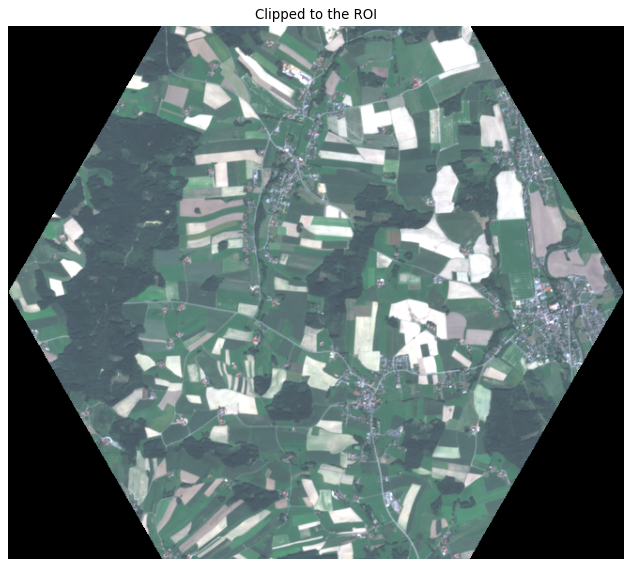

In [8]:
clipped = scene.clip_raster_with_vector(roi)
clipped.plot_composite(["red", "green", "blue"], pmin=2, pmax=98, title="Clipped to the ROI")

## Laziness and the cache

Each attribute is a `SamplePath` - inert until its file is needed. Holding one costs nothing.

In [9]:
handle = sd.copernicus_dem
print("repr before use :", repr(handle))

path = handle.path          # this is what triggers the download + verification
print("repr after use  :", repr(handle))
print("resolved path   :", path)

repr before use : <SamplePath copernicus_dem -> DEM.tif (not fetched)>
repr after use  : <SamplePath copernicus_dem -> DEM.tif (cached)>
resolved path   : /home/tommy/.cache/easy-eo/DEM.tif


`fetch()` does the same thing explicitly and returns the path. It is memoized, so the checksum is verified once per session rather than on every open.

In [10]:
from eeo.datasets import cache_dir

location = cache_dir()
print("cache:", location, "\n")

for f in sorted(location.iterdir()):
    print(f"  {f.name:28s} {f.stat().st_size / 1e6:6.1f} MB")

cache: /home/tommy/.cache/easy-eo 

  B02.tif                         1.5 MB
  B03.tif                         1.5 MB
  B04.tif                         1.6 MB
  B08.tif                         1.5 MB
  DEM.tif                         3.4 MB
  DEM_COG.tif                     5.4 MB
  roi.gpkg                        0.1 MB
  sentinel2_small.tif             5.8 MB
  sentinel2_small_cog.tif         7.9 MB


The cache location is resolved in this order:

1. `EEO_DATA_DIR`, if set
2. `XDG_CACHE_HOME/easy-eo`, if set
3. `~/.cache/easy-eo`

Set `EEO_DATA_DIR` to put the sample on a scratch disk, or to share one cache between users.

To warm everything up before going offline, pass `prefetch=True`:

```python
sd = load_sample_dataset(prefetch=True)
```

A cached file that fails its checksum is discarded and re-downloaded automatically, so a truncated download never silently becomes corrupt data.

## The COG variants

Two files are also published as Cloud-Optimized GeoTIFFs. A COG is internally tiled and carries overviews, which lets a reader fetch just the part it needs over HTTP rather than the whole file - the format that makes [02_stac_search_and_load](02_stac_search_and_load.ipynb) practical.

Locally the two behave identically; the COG is simply larger, because the overviews are stored inside it.

In [11]:
plain = load_raster(sd.sentinel2_stacked)
cog = load_raster(sd.sentinel2_cog_stacked)

import numpy as np

print("plain:", plain.get_shape(), f"{sd.sentinel2_stacked.path.stat().st_size / 1e6:.1f} MB")
print("cog  :", cog.get_shape(), f"{sd.sentinel2_cog_stacked.path.stat().st_size / 1e6:.1f} MB")
print("same values:", np.array_equal(plain.to_array(), cog.to_array()))

plain: (1024, 1024) 5.8 MB
cog  : (1024, 1024) 7.9 MB
same values: True


## Attribution

The sample is real Copernicus data and carries licence obligations. Every handle knows its own provenance — reproduce it if you publish anything derived from it.

In [12]:
print(sd.sentinel2_stacked.info())
print()
print(sd.copernicus_dem.info())

sentinel2_stacked (raster)
  Sentinel-2 L2A 4-band stack (blue/green/red/nir), 1024x1024 @ 10 m, EPSG:32633.
  file: sentinel2_small.tif
  attribution: Contains modified Copernicus Sentinel-2 L2A data 2023 (tile T33UUP, acquired 2023-09-07), processed by ESA; accessed via Microsoft Planetary Computer. Licensed under the Copernicus open data terms.

copernicus_dem (raster)
  Copernicus GLO-30 DEM warped onto the Sentinel-2 grid, float32 metres.
  file: DEM.tif
  attribution: Contains modified Copernicus DEM GLO-30 data (© DLR e.V. 2010-2014 and © Airbus Defence and Space GmbH 2014-2018, provided under COPERNICUS by the European Union and ESA); accessed via Microsoft Planetary Computer.


In [13]:
for ds in (scene, clipped, plain, cog):
    ds.close()
print("closed")

closed


## Next

- **[02_stac_search_and_load](02_stac_search_and_load.ipynb)** - fetch your own scenes instead
- **[03_xarray_interop](03_xarray_interop.ipynb)** - hand a dataset to the xarray ecosystem